# Scenario C3: Single Supplier — REC + Battery Optimization (Net Generators)

**Description:** Single supplier mandate with REC and centralized battery
storage optimisation. Two batteries (one community-scale, one residential-scale)
are co-optimised using MILP (Pyomo/GLPK) to minimise total REC energy costs.
Prosumers are modelled as **net generators** (RES only, no local load).

**Battery assets:**
| Asset | Capacity | Max Power | Efficiency | SoC Range |
|---|---|---|---|---|
| BESS_REC_01 — Community battery | 200 kWh | 68 kW | 95% | 20–100% |
| BESS_REC_02 — Prosumer residential | 80 kWh | 25 kW | 95% | 20–100% |

**Configuration:**
| Parameter | Value |
|---|---|
| Suppliers | 1 — SUP_A |
| Balancing Groups | 1 — BG_A (all 9 participants) |
| RECs | 1 — REC_01 (all 9 members, proportional sharing) |
| Prosumer type | **Net generator** (RES only, no local load) |
| REC incentives | Shared energy: 0.01 €/kWh · Self-consumption: 0.015 €/kWh |
| Optimization | MILP · Pyomo + GLPK · objective: minimize total REC cost |
| Market type | day_ahead_with_intraday_updates |
| Battery | 2 assets (community + residential) |

**Research role:** Quantifies the marginal value of battery storage on top of a
REC under a single-supplier mandate. Storage allows temporal shifting of PV surplus
into high-demand periods, increasing internal sharing ratios and reducing balancing
exposure.

**Comparison pairs:**
- C3 vs A2 → marginal value of battery storage on top of a single-supplier REC
- C3 with/without optimization → benefit of MILP dispatch vs naive battery control

## 1. Import Dependencies
Import the EnergyMarketOperations class which handles the complete market simulation pipeline.

In [1]:
from energy_market_operations import EnergyMarketOperations

## 2. Initialize Pipeline
Load the scenario configuration from JSON and create the pipeline instance. The config specifies participants, suppliers, market prices, battery parameters, and network topology.

In [2]:
CONFIG_FILE = "C3_single_supplier_rec_battery.json"
pipe = EnergyMarketOperations(CONFIG_FILE, scenario_name="C3")

## 3. Run Full Pipeline
Execute the complete market simulation:
1. **Day-Ahead Market** - Schedule energy positions based on DA forecasts
2. **Intra-Day Market** - Adjust positions with updated ID forecasts  
3. **Battery Optimization** - MILP optimization using ID forecasts to minimize grid costs
4. **REC Settlement** - Proportional energy sharing within community (with battery)
5. **Balancing Market** - Settle imbalances at dual pricing
6. **Supplier Billing** - Calculate final costs per participant

## Battery Scheduling — LGS MILP Formulation

The battery is scheduled by solving a **Mixed-Integer Linear Programme (MILP)** over a rolling 24-hour horizon (96 × 15-min steps), repeated once per day across the full simulation year.

---

### Sets and indices
| Symbol | Description |
|--------|-------------|
| $\mathcal{T} = \{0,\dots,T{-}1\}$ | Time steps in one rolling block ($T = 96$) |
| $\mathcal{B}$ | Set of batteries in the REC |

---

### Parameters (per battery $b \in \mathcal{B}$)

| Parameter | Description |
|-----------|-------------|
| $\Delta t = 0.25\,\text{h}$ | Step duration |
| $\overline{P}^{ch}_b,\; \overline{P}^{dis}_b$ | Max charge / discharge power (kW) |
| $\eta^{ch}_b,\; \eta^{dis}_b$ | Charge / discharge efficiencies |
| $E^{min}_b,\; E^{max}_b$ | SOC bounds (kWh): $E^{min} = 0.20\,E^{cap}$, $E^{max} = E^{cap}$ |
| $E^{0}_b$ | SOC at start of block (terminal SOC from previous block) |
| $\hat{P}^{load}_t$ | Aggregated REC load forecast at step $t$ (kW) |
| $\hat{P}^{gen}_t$ | Aggregated REC generation forecast at step $t$ (kW) |
| $\lambda^{ret}_t,\; \lambda^{fi}_t$ | Retail price / feed-in tariff at step $t$ (€/kWh) |

---

### Decision variables

| Variable | Domain | Description |
|----------|--------|-------------|
| $x^{ch}_{b,t}$ | $[0,\; \overline{P}^{ch}_b]$ | Charge power (kW) |
| $x^{dis}_{b,t}$ | $[0,\; \overline{P}^{dis}_b]$ | Discharge power (kW) |
| $E_{b,t}$ | $[E^{min}_b,\; E^{max}_b]$ | State of charge (kWh) |
| $P^{imp}_t$ | $\geq 0$ | Grid import power (kW) |
| $P^{exp}_t$ | $\geq 0$ | Grid export power (kW) |
| $u_{b,t}$ | $\{0,1\}$ | Binary: 1 = charging, 0 = discharging |

---

### Objective — minimise expected grid cost

$$
\min \;\; \Delta t \sum_{t \in \mathcal{T}} \Bigl( \lambda^{ret}_t \, P^{imp}_t \;-\; \lambda^{fi}_t \, P^{exp}_t \Bigr)
$$

---

### Constraints

**Energy balance (LGS meter equation)** — grid + battery covers net REC demand:

$$
P^{imp}_t - P^{exp}_t + x^{dis}_{b,t} - x^{ch}_{b,t} \;=\; \hat{P}^{load}_t - \hat{P}^{gen}_t \qquad \forall\, t \in \mathcal{T}
$$

**SOC dynamics:**

$$
E_{b,t} = E_{b,t-1} \;+\; \eta^{ch}_b\, x^{ch}_{b,t}\,\Delta t \;-\; \frac{x^{dis}_{b,t}}{\eta^{dis}_b}\,\Delta t \qquad \forall\, t \in \mathcal{T},\quad E_{b,-1} = E^{0}_b
$$

**No-simultaneous charge/discharge (binary):**

$$
x^{ch}_{b,t} \;\leq\; \overline{P}^{ch}_b \, u_{b,t}, \qquad x^{dis}_{b,t} \;\leq\; \overline{P}^{dis}_b \,(1 - u_{b,t}) \qquad \forall\, t
$$

**Terminal SOC constraint** — prevents SOC drift to minimum across the horizon:

$$
E_{b,T-1} \;\geq\; E^{0}_b
$$

**SOC bounds:**

$$
E^{min}_b \;\leq\; E_{b,t} \;\leq\; E^{max}_b \qquad \forall\, t
$$

---

### Rolling-horizon execution

The 24-hour block is solved repeatedly: the terminal SOC $E_{b,T-1}$ from block $k$ becomes $E^{0}_b$ for block $k+1$, propagating battery state across the full year.


In [3]:
pipe.run_all()


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Running full pipeline for: C3
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  SCENARIO: C3
  System  : Single Supplier Mandate with REC and Battery Optimization - Scenario C3
  Period  : 2016-01-01 → 2016-12-31
  Suppliers    : 1
  Prosumers    : 3
  Consumers    : 6
  RECs         : 1  →  has_rec = True
  Battery      : True
✓ Prices loaded: (35136, 5)  from prices.csv
✓ Load actual : (35136, 153)
✓ RES actual  : (35136, 27)
✓ Load forecast DA: (35136, 6)
✓ RES  forecast DA: (35136, 3)
✓ Load forecast ID: (35136, 6)
✓ RES  forecast ID: (35136, 3)
✓ Storage actual: (35136, 16)
✓ DA market: (35136, 8)
✓ ID market : (35136, 19)
  Rolling-horizon LGS battery optimization: 2 batteries, block 24h (96 periods), total 35136 periods
    [BESS_REC_01] Centralized REC Community Battery: 200 kWh, ±68/68 kW, SOC [40–200] kWh
Restricted license - for non-production use only - expi

## 4. Financial Summary
Display aggregated financial results including total revenues, costs, and profit/loss for the supplier.

In [4]:
pipe.summary()


  ANNUAL FINANCIAL SUMMARY – C3

  SUP_A (Supplier A):

    REVENUES:
      Energy Market Sales : €      283.12
      Balancing Rewards   : €       71.15
      Retail Sales        : €   21,123.93
      ────────────────────────────────────────────
      Total Revenue       : €   21,478.19

    COSTS:
      Market Purchases    : €    3,463.56
      Balancing Penalties  : €       70.57
      Retail Purchases     : €    1,107.46
      ────────────────────────────────────────────
      Total Costs          : €    4,641.59

    PROFIT/LOSS:
      Annual Total         : €   16,836.60
      Monthly Average      : €    1,403.05

    IMBALANCE:
      System Position      : SHORT
      Total Imbalance      :         0.01 MWh
      BG Actual Position   :        91.65 MWh
      BG Forecast Position :        91.65 MWh

    REC SHARING:
      Shared Energy        :        86.47 MWh



## 5. Financial Visualization
Plot breakdown of revenues and costs by category (DA purchases, ID adjustments, balancing costs, customer sales).

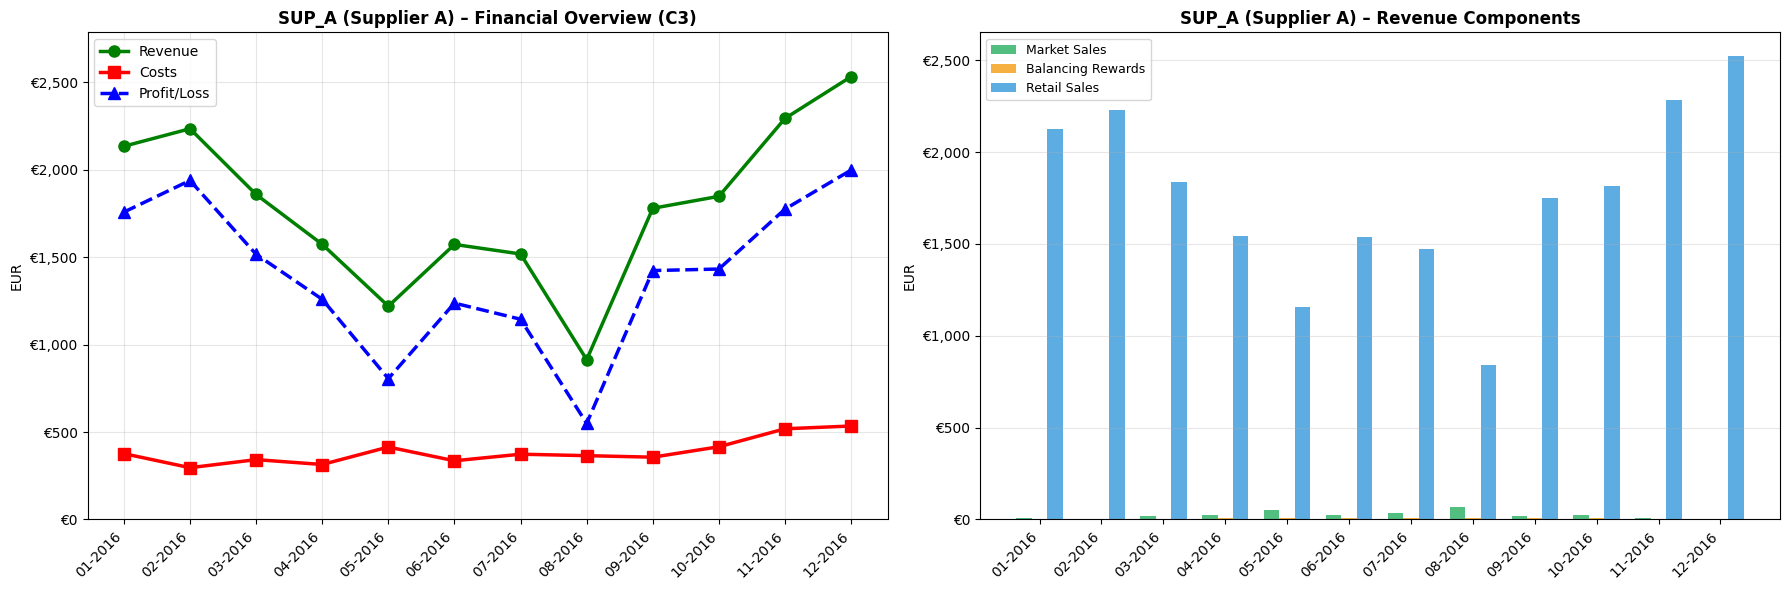

In [5]:
pipe.plot_financials()

## 6. Imbalance Analysis
Visualize system imbalances over time showing the difference between scheduled positions and actual metered values.

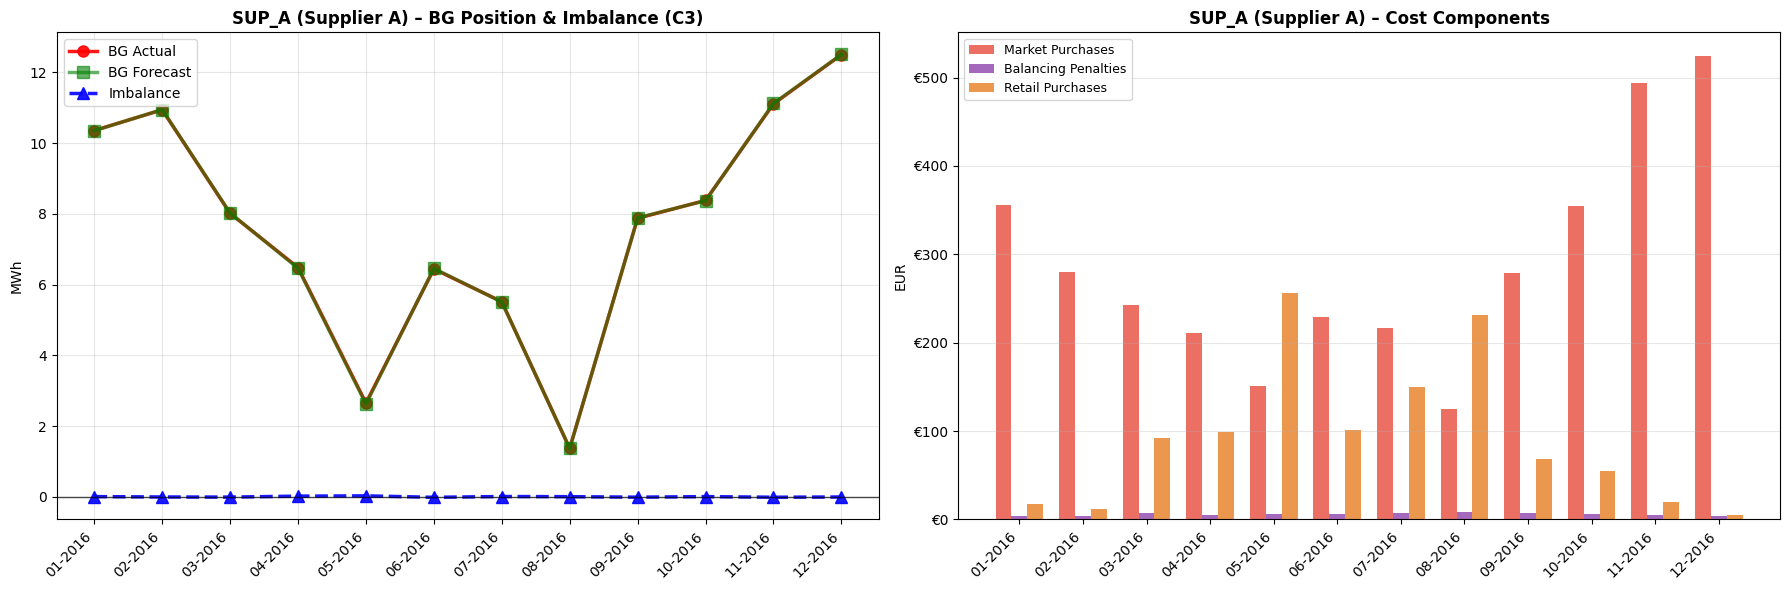

In [6]:
pipe.plot_imbalances()

## 7. Battery Optimization Results
Visualize the battery state of charge (SOC) and charge/discharge patterns over the full year.
One figure is produced per battery in the REC.


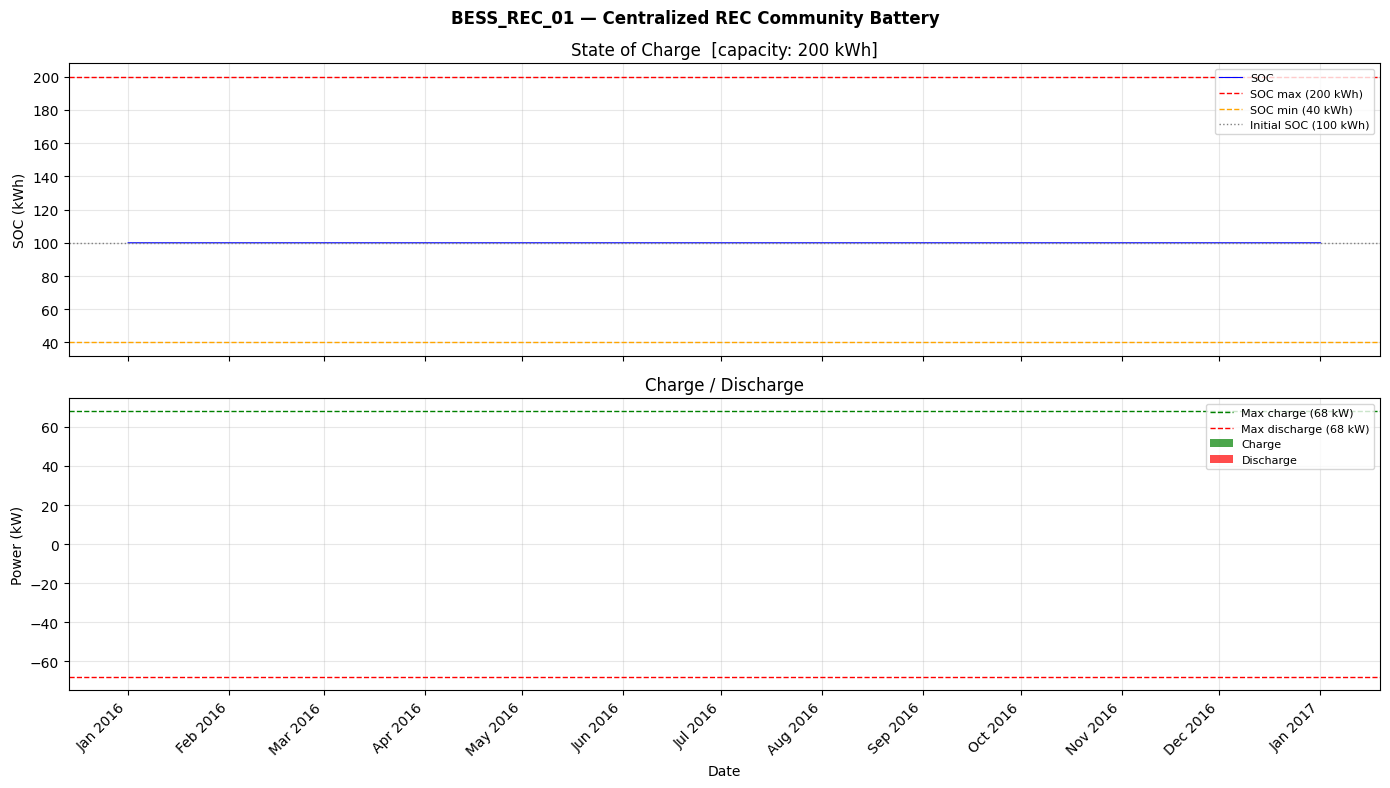

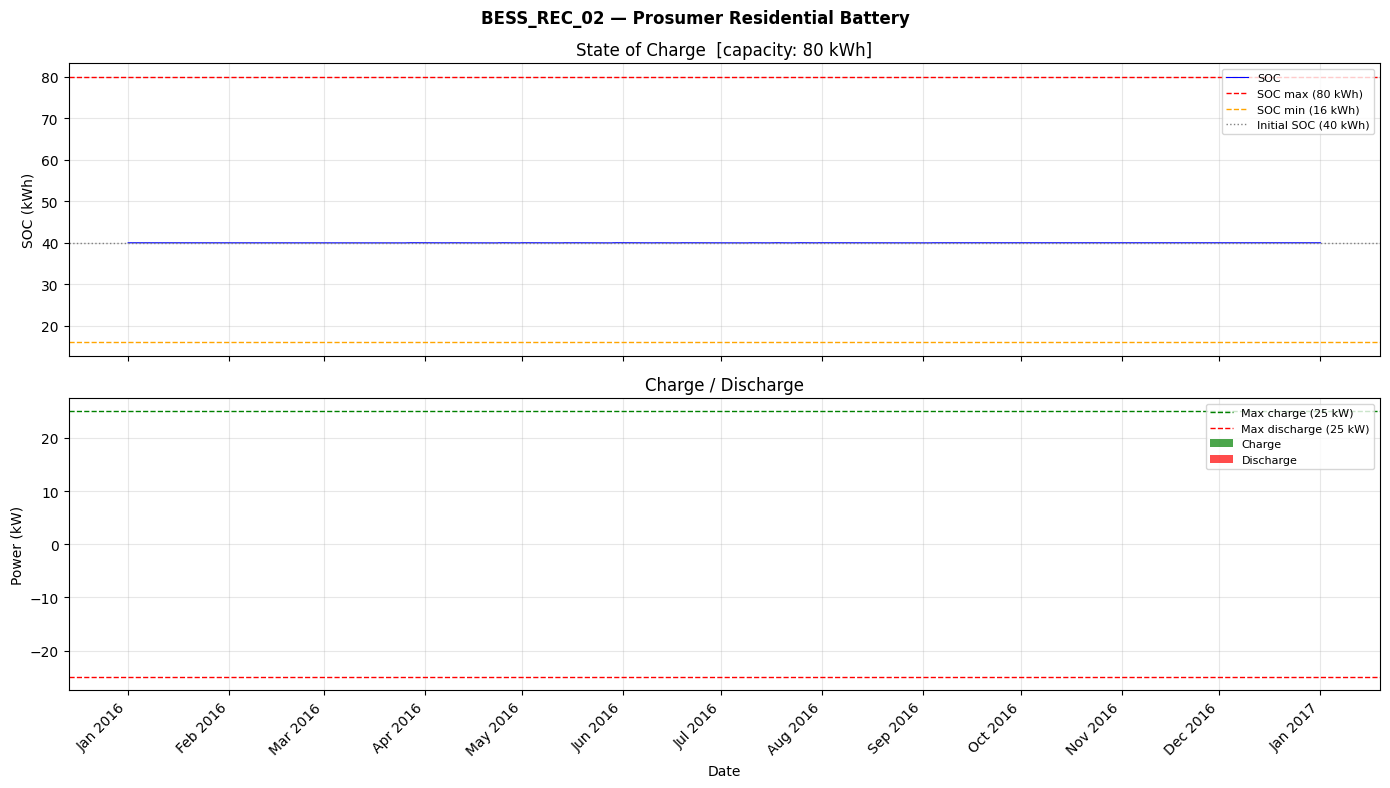

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Normalise: build {battery_id: (schedule_df, tech_params)} from all available batteries
batteries_raw = pipe.config.get('batteries', pipe.config.get('battery_storage'))
if isinstance(batteries_raw, dict):
    batteries_raw = [batteries_raw]

battery_cfgs = {b['battery_id']: b.get('technical_parameters', {}) for b in batteries_raw}

# Use per-battery schedules if available, fall back to single aggregated schedule
schedules = getattr(pipe, 'battery_schedules', None) or {}
if not schedules and hasattr(pipe, 'battery_schedule_df') and not pipe.battery_schedule_df.empty:
    # Single-battery backward compat
    batt_id = list(battery_cfgs.keys())[0]
    schedules = {batt_id: pipe.battery_schedule_df}

if not schedules:
    print("Battery optimization results not available")
else:
    for batt_id, df in schedules.items():
        tech = battery_cfgs.get(batt_id, {})
        capacity_kwh     = tech.get('capacity_kwh', 200)
        max_charge_kw    = tech.get('max_charge_power_kw', 68)
        max_discharge_kw = tech.get('max_discharge_power_kw', 68)
        soc_min_kwh      = capacity_kwh * tech.get('soc_min_percent', 20)  / 100.0
        soc_max_kwh      = capacity_kwh * tech.get('soc_max_percent', 100) / 100.0
        initial_soc_kwh  = capacity_kwh * tech.get('initial_soc_percent', 50) / 100.0

        batt_name = next((b['battery_name'] for b in batteries_raw if b['battery_id'] == batt_id), batt_id)

        fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
        fig.suptitle(f'{batt_id} — {batt_name}', fontsize=12, fontweight='bold')

        dates = df.index

        # SOC with reference lines
        axes[0].plot(dates, df['soc_kwh'], label='SOC', color='blue', linewidth=0.8)
        axes[0].axhline(soc_max_kwh,     color='red',    linestyle='--', linewidth=1.0,
                        label=f'SOC max ({soc_max_kwh:.0f} kWh)')
        axes[0].axhline(soc_min_kwh,     color='orange', linestyle='--', linewidth=1.0,
                        label=f'SOC min ({soc_min_kwh:.0f} kWh)')
        axes[0].axhline(initial_soc_kwh, color='gray',   linestyle=':',  linewidth=1.0,
                        label=f'Initial SOC ({initial_soc_kwh:.0f} kWh)')
        axes[0].set_ylabel('SOC (kWh)')
        axes[0].legend(loc='upper right', fontsize=8)
        axes[0].set_title(f'State of Charge  [capacity: {capacity_kwh} kWh]')
        axes[0].grid(True, alpha=0.3)

        # Charge/discharge with power limit lines
        axes[1].bar(dates, df['charge_kw'],
                    width=pd.Timedelta('15min'), color='green', alpha=0.7, label='Charge')
        axes[1].bar(dates, -df['discharge_kw'],
                    width=pd.Timedelta('15min'), color='red',   alpha=0.7, label='Discharge')
        axes[1].axhline( max_charge_kw,    color='green', linestyle='--', linewidth=1.0,
                         label=f'Max charge ({max_charge_kw} kW)')
        axes[1].axhline(-max_discharge_kw, color='red',   linestyle='--', linewidth=1.0,
                         label=f'Max discharge ({max_discharge_kw} kW)')
        axes[1].set_ylabel('Power (kW)')
        axes[1].set_xlabel('Date')
        axes[1].legend(loc='upper right', fontsize=8)
        axes[1].set_title('Charge / Discharge')
        axes[1].grid(True, alpha=0.3)

        axes[1].xaxis.set_major_locator(mdates.MonthLocator())
        axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        fig.autofmt_xdate(rotation=45)
        plt.tight_layout()
        plt.show()


## 8. REC + Battery Summary
Display combined REC sharing and battery usage statistics with monthly analysis data.

In [8]:
print("=== C3 REC + Battery Summary ===")
print(f"Total Shared Energy: {pipe.es_monthly_analysis_df['internal_shared_energy_mwh'].sum():,.2f} MWh")

schedules = getattr(pipe, 'battery_schedules', None) or {}
if not schedules and hasattr(pipe, 'battery_schedule_df') and not pipe.battery_schedule_df.empty:
    schedules = {'BESS_REC_01': pipe.battery_schedule_df}

for batt_id, df in schedules.items():
    total_ch  = df['charge_kw'].sum()    * 0.25 / 1000
    total_dis = df['discharge_kw'].sum() * 0.25 / 1000
    print(f"  [{batt_id}] Charge: {total_ch:,.2f} MWh  |  Discharge: {total_dis:,.2f} MWh")

pipe.es_monthly_analysis_df


=== C3 REC + Battery Summary ===
Total Shared Energy: 86.47 MWh
  [BESS_REC_01] Charge: 0.00 MWh  |  Discharge: 0.00 MWh
  [BESS_REC_02] Charge: 0.00 MWh  |  Discharge: 0.00 MWh


,datetime,supplier_id,balancing_group_id,da_net_load_forecast_mwh,da_net_gen_forecast_mwh,da_purchase_commitment_eur,da_sale_commitment_eur,id_net_load_adjustment_mwh,id_net_gen_adjustment_mwh,id_price_eur_per_mwh,...,internal_shared_energy_mwh,revenue_energy_market_sales_eur,revenue_balancing_rewards_eur,revenue_retail_sales_eur,total_revenue_eur,cost_energy_market_purchases_eur,cost_balancing_penalties_eur,cost_retail_purchases_eur,total_costs_eur,profit_loss_eur
0,01-2016,SUP_A,BG_A,11.740290,0.180791,395.381203,4.664840,-1.175045,0.030932,29.579375,...,2.830740,5.529485,4.009907,2124.610587,2134.149978,355.532769,3.465164,17.445818,376.443751,1757.706227
1,02-2016,SUP_A,BG_A,12.437626,0.121162,314.480153,1.882415,-1.345223,0.021096,22.463459,...,5.166612,2.230811,4.371368,2227.909681,2234.511860,280.228549,4.270064,11.479986,295.978598,1938.533261
2,03-2016,SUP_A,BG_A,10.352735,1.026866,274.725242,15.168111,-1.208871,0.091983,24.094009,...,8.053855,17.181040,5.183383,1835.981919,1858.346342,242.508724,7.437098,92.125373,342.071195,1516.275147
3,04-2016,SUP_A,BG_A,8.797402,1.032603,241.398511,19.683030,-1.127719,0.173916,25.257687,...,10.424519,23.901538,5.622824,1543.789923,1573.314285,210.669928,4.842401,98.756626,314.268956,1259.045329
4,05-2016,SUP_A,BG_A,6.573481,2.838498,173.232440,44.972758,-0.817546,0.292393,22.993579,...,10.051994,51.825879,9.036340,1158.746094,1219.608314,151.316925,6.396274,256.569430,414.282629,805.325685
5,06-2016,SUP_A,BG_A,8.714424,1.064149,260.907549,21.989673,-1.039799,0.152722,27.651608,...,8.873123,25.999581,6.102997,1540.705861,1572.808439,229.172007,5.689004,100.718614,335.579625,1237.228814
6,07-2016,SUP_A,BG_A,8.391116,1.604744,247.727572,31.466332,-1.056170,0.221446,27.138380,...,10.686351,37.108990,7.205016,1473.856573,1518.170580,216.402585,7.160590,149.652266,373.215442,1144.955138
7,08-2016,SUP_A,BG_A,4.780504,2.522270,142.692441,58.390462,-0.596044,0.295230,27.268374,...,9.241013,66.161635,7.847995,839.869441,913.879070,124.678803,8.750842,231.413630,364.843275,549.035796
8,09-2016,SUP_A,BG_A,9.887178,0.704498,316.982297,17.102633,-1.173166,0.121973,30.137590,...,8.898765,20.628851,7.436418,1751.414876,1779.480145,279.304556,7.860264,68.948406,356.113226,1423.366919
9,10-2016,SUP_A,BG_A,10.156405,0.581479,398.922563,19.880555,-1.103117,0.095788,36.908256,...,5.754070,23.348741,6.078231,1818.460150,1847.887122,354.876465,6.015983,54.890263,415.782711,1432.104411


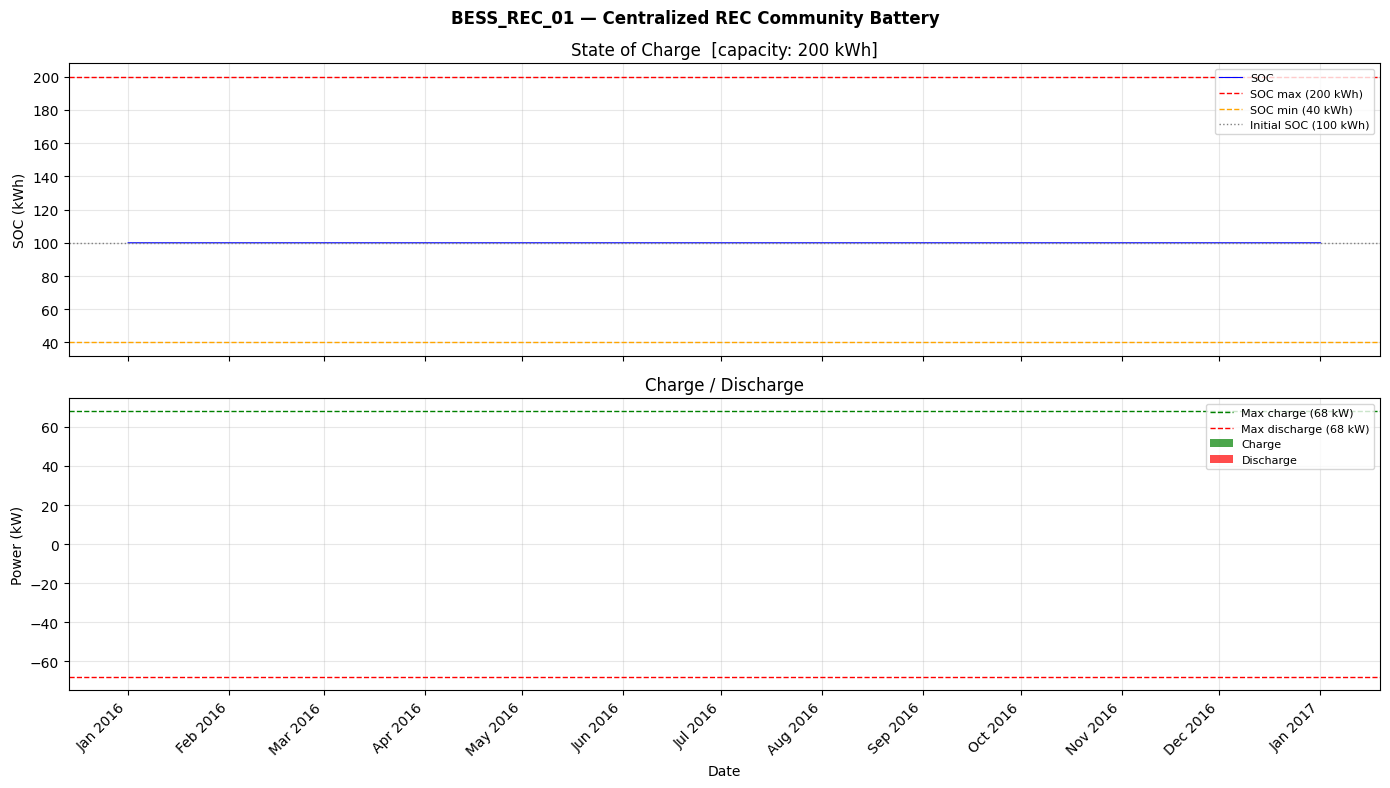

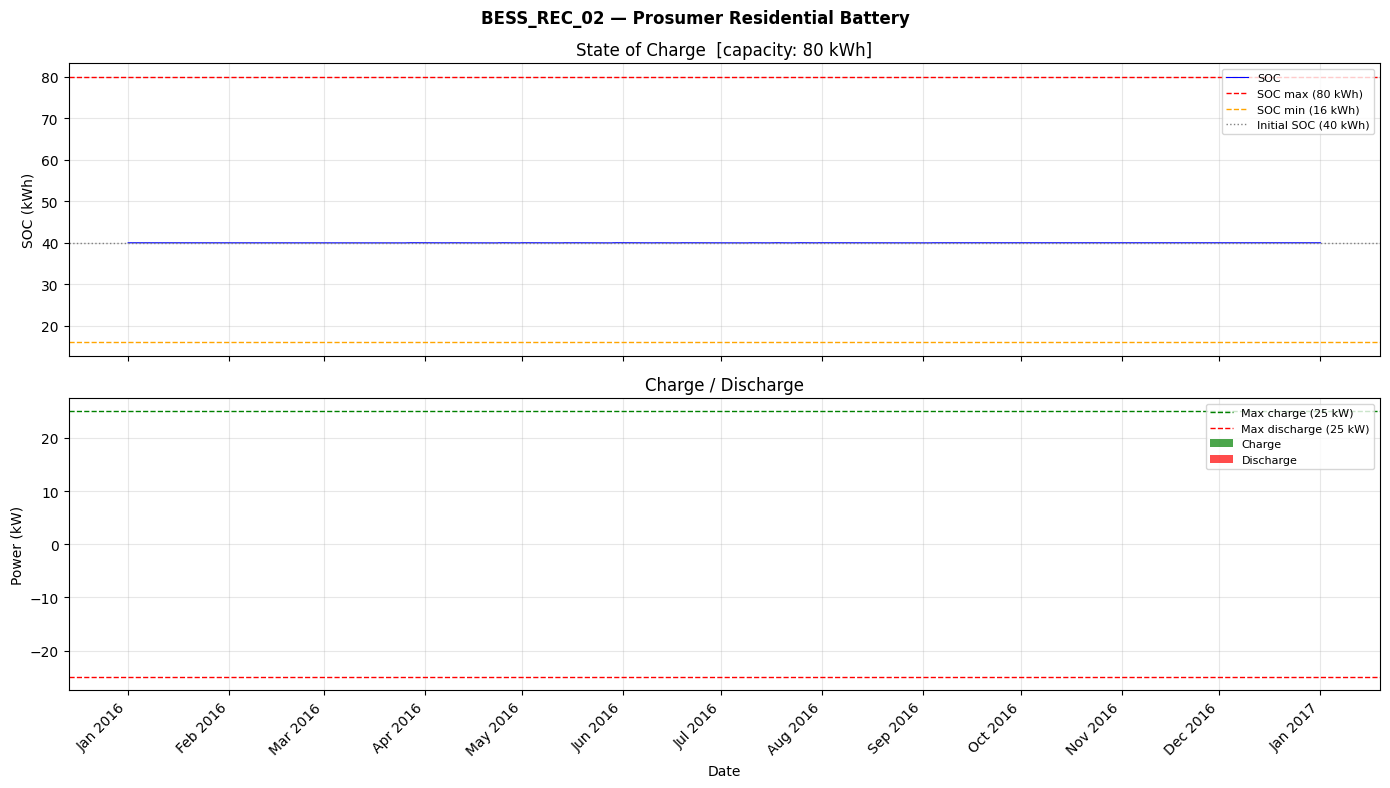

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Normalise: build {battery_id: (schedule_df, tech_params)} from all available batteries
batteries_raw = pipe.config.get('batteries', pipe.config.get('battery_storage'))
if isinstance(batteries_raw, dict):
    batteries_raw = [batteries_raw]

battery_cfgs = {b['battery_id']: b.get('technical_parameters', {}) for b in batteries_raw}

# Use per-battery schedules if available, fall back to single aggregated schedule
schedules = getattr(pipe, 'battery_schedules', None) or {}
if not schedules and hasattr(pipe, 'battery_schedule_df') and not pipe.battery_schedule_df.empty:
    batt_id = list(battery_cfgs.keys())[0]
    schedules = {batt_id: pipe.battery_schedule_df}

if not schedules:
    print("Battery optimization results not available")
else:
    for batt_id, df in schedules.items():
        tech = battery_cfgs.get(batt_id, {})
        capacity_kwh     = tech.get('capacity_kwh', 200)
        max_charge_kw    = tech.get('max_charge_power_kw', 68)
        max_discharge_kw = tech.get('max_discharge_power_kw', 68)
        soc_min_kwh      = capacity_kwh * tech.get('soc_min_percent', 20)  / 100.0
        soc_max_kwh      = capacity_kwh * tech.get('soc_max_percent', 100) / 100.0
        initial_soc_kwh  = capacity_kwh * tech.get('initial_soc_percent', 50) / 100.0

        batt_name = next((b['battery_name'] for b in batteries_raw if b['battery_id'] == batt_id), batt_id)

        fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
        fig.suptitle(f'{batt_id} — {batt_name}', fontsize=12, fontweight='bold')

        dates = df.index

        axes[0].plot(dates, df['soc_kwh'], label='SOC', color='blue', linewidth=0.8)
        axes[0].axhline(soc_max_kwh,     color='red',    linestyle='--', linewidth=1.0,
                        label=f'SOC max ({soc_max_kwh:.0f} kWh)')
        axes[0].axhline(soc_min_kwh,     color='orange', linestyle='--', linewidth=1.0,
                        label=f'SOC min ({soc_min_kwh:.0f} kWh)')
        axes[0].axhline(initial_soc_kwh, color='gray',   linestyle=':',  linewidth=1.0,
                        label=f'Initial SOC ({initial_soc_kwh:.0f} kWh)')
        axes[0].set_ylabel('SOC (kWh)')
        axes[0].legend(loc='upper right', fontsize=8)
        axes[0].set_title(f'State of Charge  [capacity: {capacity_kwh} kWh]')
        axes[0].grid(True, alpha=0.3)

        axes[1].bar(dates, df['charge_kw'],
                    width=pd.Timedelta('15min'), color='green', alpha=0.7, label='Charge')
        axes[1].bar(dates, -df['discharge_kw'],
                    width=pd.Timedelta('15min'), color='red',   alpha=0.7, label='Discharge')
        axes[1].axhline( max_charge_kw,    color='green', linestyle='--', linewidth=1.0,
                         label=f'Max charge ({max_charge_kw} kW)')
        axes[1].axhline(-max_discharge_kw, color='red',   linestyle='--', linewidth=1.0,
                         label=f'Max discharge ({max_discharge_kw} kW)')
        axes[1].set_ylabel('Power (kW)')
        axes[1].set_xlabel('Date')
        axes[1].legend(loc='upper right', fontsize=8)
        axes[1].set_title('Charge / Discharge')
        axes[1].grid(True, alpha=0.3)

        axes[1].xaxis.set_major_locator(mdates.MonthLocator())
        axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        fig.autofmt_xdate(rotation=45)
        plt.tight_layout()
        plt.show()


In [10]:
# REC + Battery Analysis
print("=== C3 Summary ===")
print(f"Total Shared Energy: {pipe.es_monthly_analysis_df['internal_shared_energy_mwh'].sum():,.2f} MWh")

schedules = getattr(pipe, 'battery_schedules', None) or {}
if not schedules and hasattr(pipe, 'battery_schedule_df') and not pipe.battery_schedule_df.empty:
    schedules = {'BESS_REC_01': pipe.battery_schedule_df}

for batt_id, df in schedules.items():
    total_ch  = df['charge_kw'].sum()    * 0.25 / 1000
    total_dis = df['discharge_kw'].sum() * 0.25 / 1000
    print(f"  [{batt_id}] Charge: {total_ch:,.2f} MWh  |  Discharge: {total_dis:,.2f} MWh")

pipe.es_monthly_analysis_df


=== C3 Summary ===
Total Shared Energy: 86.47 MWh
  [BESS_REC_01] Charge: 0.00 MWh  |  Discharge: 0.00 MWh
  [BESS_REC_02] Charge: 0.00 MWh  |  Discharge: 0.00 MWh


,datetime,supplier_id,balancing_group_id,da_net_load_forecast_mwh,da_net_gen_forecast_mwh,da_purchase_commitment_eur,da_sale_commitment_eur,id_net_load_adjustment_mwh,id_net_gen_adjustment_mwh,id_price_eur_per_mwh,...,internal_shared_energy_mwh,revenue_energy_market_sales_eur,revenue_balancing_rewards_eur,revenue_retail_sales_eur,total_revenue_eur,cost_energy_market_purchases_eur,cost_balancing_penalties_eur,cost_retail_purchases_eur,total_costs_eur,profit_loss_eur
0,01-2016,SUP_A,BG_A,11.740290,0.180791,395.381203,4.664840,-1.175045,0.030932,29.579375,...,2.830740,5.529485,4.009907,2124.610587,2134.149978,355.532769,3.465164,17.445818,376.443751,1757.706227
1,02-2016,SUP_A,BG_A,12.437626,0.121162,314.480153,1.882415,-1.345223,0.021096,22.463459,...,5.166612,2.230811,4.371368,2227.909681,2234.511860,280.228549,4.270064,11.479986,295.978598,1938.533261
2,03-2016,SUP_A,BG_A,10.352735,1.026866,274.725242,15.168111,-1.208871,0.091983,24.094009,...,8.053855,17.181040,5.183383,1835.981919,1858.346342,242.508724,7.437098,92.125373,342.071195,1516.275147
3,04-2016,SUP_A,BG_A,8.797402,1.032603,241.398511,19.683030,-1.127719,0.173916,25.257687,...,10.424519,23.901538,5.622824,1543.789923,1573.314285,210.669928,4.842401,98.756626,314.268956,1259.045329
4,05-2016,SUP_A,BG_A,6.573481,2.838498,173.232440,44.972758,-0.817546,0.292393,22.993579,...,10.051994,51.825879,9.036340,1158.746094,1219.608314,151.316925,6.396274,256.569430,414.282629,805.325685
5,06-2016,SUP_A,BG_A,8.714424,1.064149,260.907549,21.989673,-1.039799,0.152722,27.651608,...,8.873123,25.999581,6.102997,1540.705861,1572.808439,229.172007,5.689004,100.718614,335.579625,1237.228814
6,07-2016,SUP_A,BG_A,8.391116,1.604744,247.727572,31.466332,-1.056170,0.221446,27.138380,...,10.686351,37.108990,7.205016,1473.856573,1518.170580,216.402585,7.160590,149.652266,373.215442,1144.955138
7,08-2016,SUP_A,BG_A,4.780504,2.522270,142.692441,58.390462,-0.596044,0.295230,27.268374,...,9.241013,66.161635,7.847995,839.869441,913.879070,124.678803,8.750842,231.413630,364.843275,549.035796
8,09-2016,SUP_A,BG_A,9.887178,0.704498,316.982297,17.102633,-1.173166,0.121973,30.137590,...,8.898765,20.628851,7.436418,1751.414876,1779.480145,279.304556,7.860264,68.948406,356.113226,1423.366919
9,10-2016,SUP_A,BG_A,10.156405,0.581479,398.922563,19.880555,-1.103117,0.095788,36.908256,...,5.754070,23.348741,6.078231,1818.460150,1847.887122,354.876465,6.015983,54.890263,415.782711,1432.104411
